# Credit Card Approval Prediction System

**Setup:**
1. Create/activate a virtual environment (Optional).
2. Install dependencies: `pip install numpy pandas matplotlib seaborn scikit-learn xgboost joblib scipy`
3. Place the dataset CSVs in a local `data/` folder at the project root:
   - `data/application_record.csv`
   - `data/credit_record.csv`
4. Run cells top-to-bottom.


In [1]:
# --- Step 2: Load the Dataset (local /data folder, VS Code) ---
# Previously this cell pulled the dataset from Kaggle's mounted input path.
# Since we're now working locally in VS Code, the two CSVs are expected in
# a `data/` folder at the project root (already downloaded from Kaggle manually).

import os

DATA_DIR = "data"

expected_files = {"application_record.csv", "credit_record.csv"}
found_files = set(os.listdir(DATA_DIR))

missing = expected_files - found_files
if missing:
    raise FileNotFoundError(
        f"Missing expected file(s) in '{DATA_DIR}/': {missing}. "
        f"Make sure both CSVs from the Kaggle dataset are placed in that folder."
    )

print("Files found:", sorted(found_files))


Files found: ['application_record.csv', 'credit_record.csv']


In [3]:
# --- Step 3: Importing the Libraries ---

# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Clustering (used later for catalog/record dedup if needed)
# from sklearn.cluster import DBSCAN

# Model persistence
import joblib

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot styling
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# --- Step 4: Read the Dataset ---

# Load the two CSV files
application_df = pd.read_csv(f"{DATA_DIR}/application_record.csv")
credit_df = pd.read_csv(f"{DATA_DIR}/credit_record.csv")

# --- Quick look at application_record.csv ---
print("Application Record Shape:", application_df.shape)
application_df.head()

Application Record Shape: (438557, 18)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [4]:
print("Credit Record Shape:", credit_df.shape)
credit_df.head()

Credit Record Shape: (1048575, 3)


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [5]:
# --- Structure & datatypes ---
print("=== Application Record Info ===")
application_df.info()

print("\n=== Credit Record Info ===")
credit_df.info()

=== Application Record Info ===
<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 

In [6]:
# --- Basic stats ---
print("=== Application Record Summary ===")
display(application_df.describe(include="all").T)

print("\n=== Credit Record Summary ===")
display(credit_df.describe(include="all").T)

=== Application Record Summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,438557.0,NaN,NaN,NaN,6022176.269842,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CODE_GENDER,438557,2,F,294440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,438557,2,N,275459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,438557,2,Y,304074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,438557.0,NaN,NaN,NaN,0.42739,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,NaN,NaN,NaN,187524.28601,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
NAME_INCOME_TYPE,438557,5,Working,226104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_EDUCATION_TYPE,438557,5,Secondary / secondary special,301821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_FAMILY_STATUS,438557,5,Married,299828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_HOUSING_TYPE,438557,6,House / apartment,393831,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== Credit Record Summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,1048575.0,NaN,NaN,NaN,5068286.424673,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,NaN,NaN,NaN,-19.136998,14.023498,-60.0,-29.0,-17.0,-7.0,0.0
STATUS,1048575,8,C,442031,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# --- Check unique applicant counts ---
print("Unique applicants in application_record:", application_df["ID"].nunique())
print("Unique applicants in credit_record:", credit_df["ID"].nunique())

# Some applicants exist in one file but not the other — worth flagging early
only_in_app = set(application_df["ID"]) - set(credit_df["ID"])
only_in_credit = set(credit_df["ID"]) - set(application_df["ID"])
print(f"IDs only in application_record: {len(only_in_app)}")
print(f"IDs only in credit_record: {len(only_in_credit)}")

Unique applicants in application_record: 438510
Unique applicants in credit_record: 45985
IDs only in application_record: 402053
IDs only in credit_record: 9528


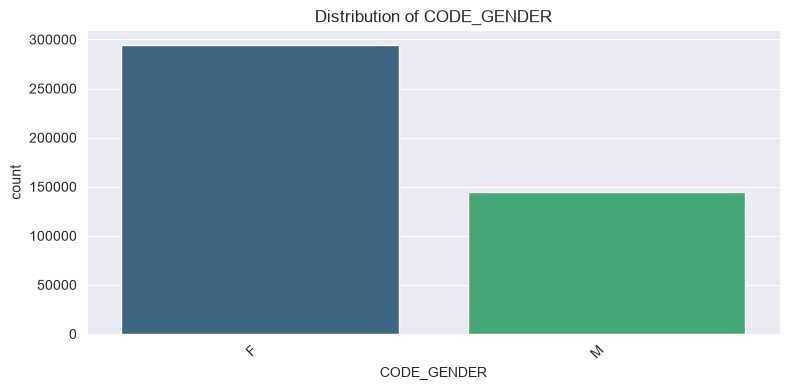

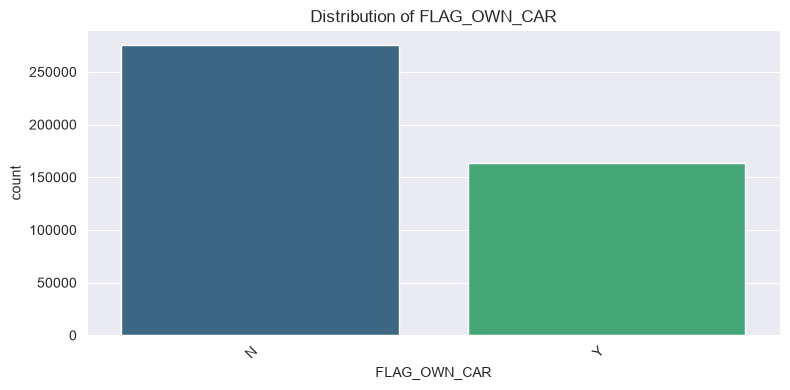

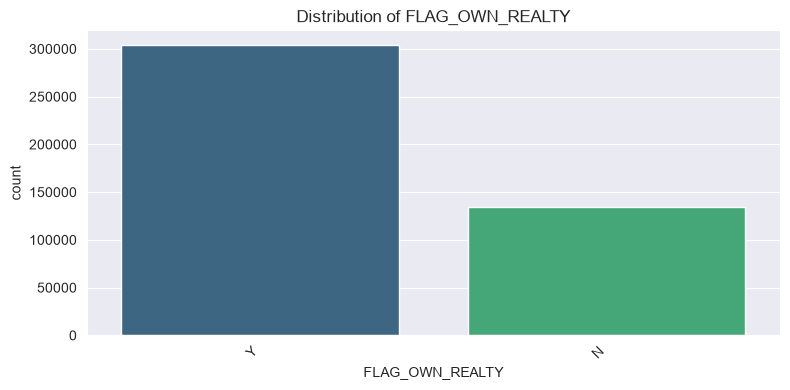

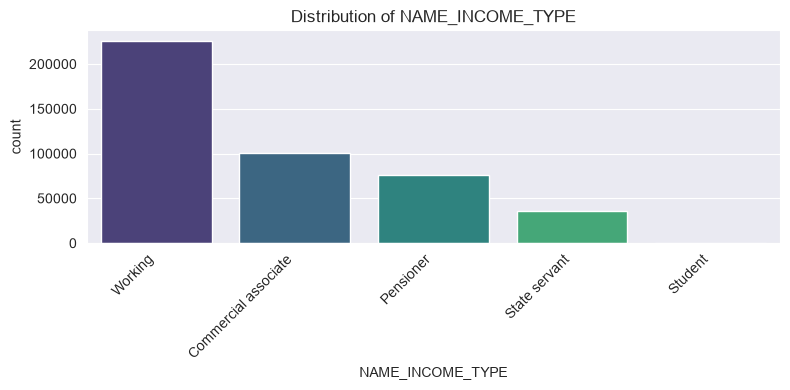

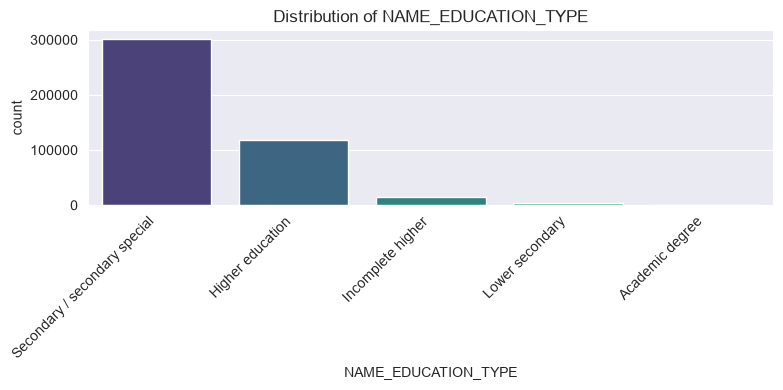

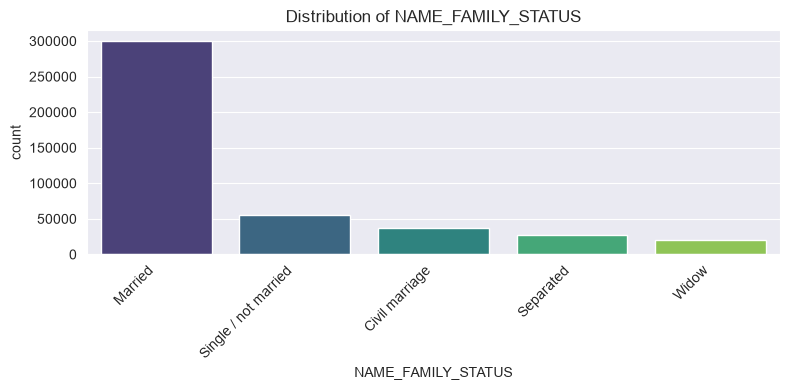

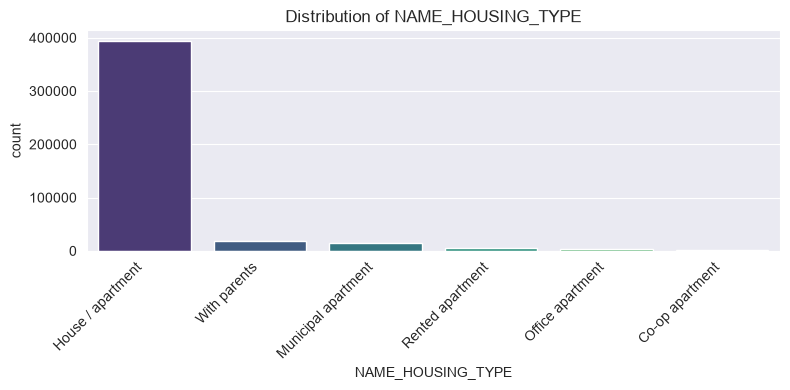

In [8]:
# --- Step 5: Univariate Analysis ---

# 1. Categorical features - count plots
categorical_cols = [
    "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE"
]

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=application_df, x=col, order=application_df[col].value_counts().index,
                  palette="viridis")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

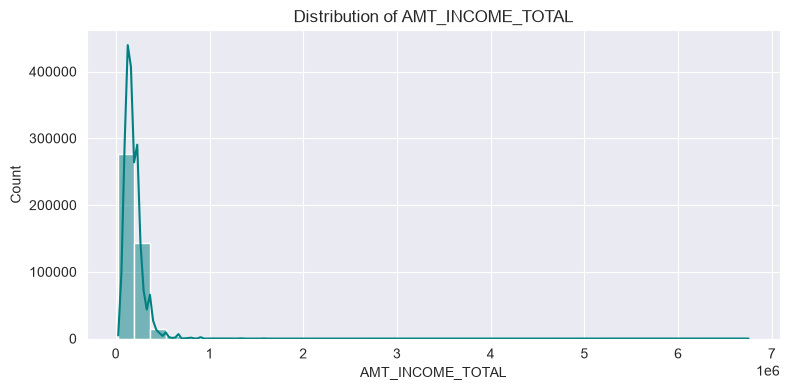

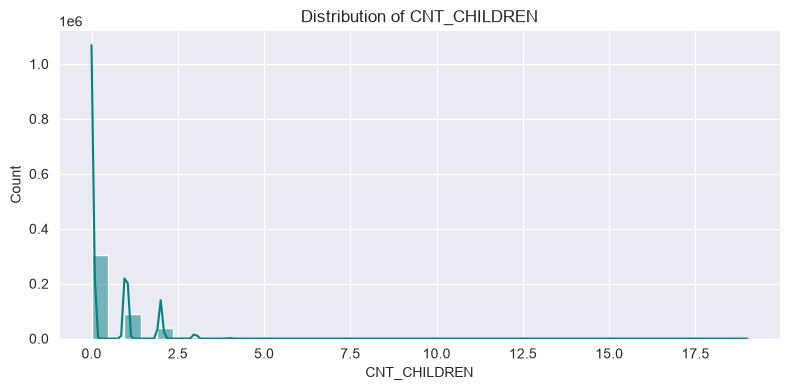

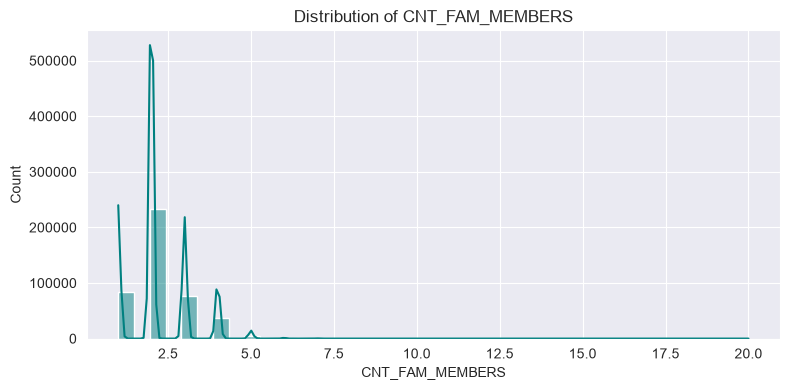

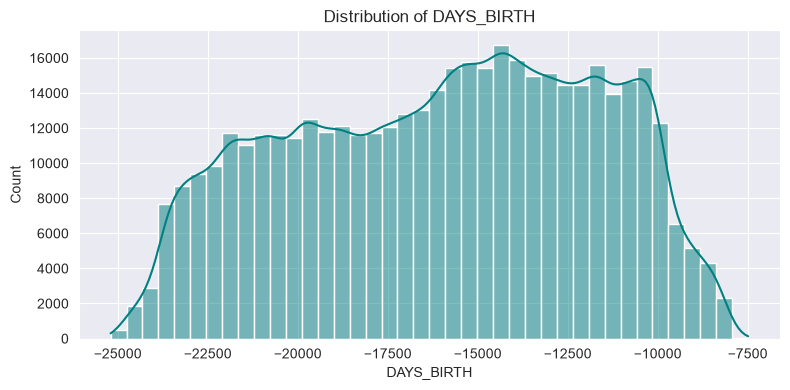

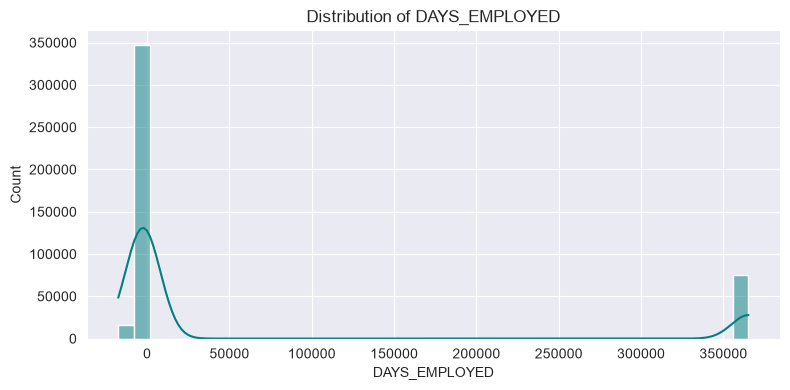

In [9]:
# 2. Numerical features - distribution plots
numerical_cols = ["AMT_INCOME_TOTAL", "CNT_CHILDREN", "CNT_FAM_MEMBERS", "DAYS_BIRTH", "DAYS_EMPLOYED"]

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(application_df[col], kde=True, bins=40, color="teal")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

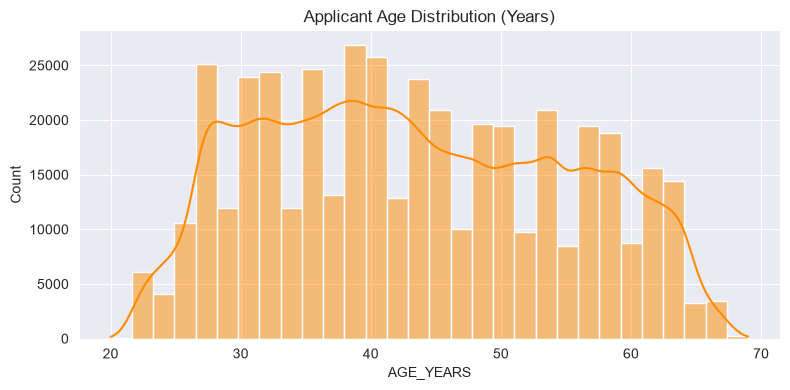

Applicants with DAYS_EMPLOYED placeholder (365243, i.e. not employed): 75329


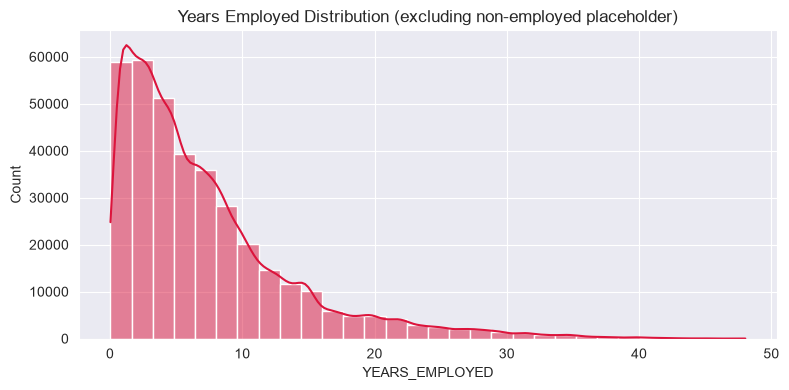

In [10]:
# 3. Convert DAYS_BIRTH / DAYS_EMPLOYED into readable units for a clearer view
# (DAYS_BIRTH is negative days from today; DAYS_EMPLOYED has a known placeholder value
# of 365243 for unemployed/pensioner applicants — worth flagging as an outlier)

application_df["AGE_YEARS"] = (-application_df["DAYS_BIRTH"] / 365).astype(int)
application_df["YEARS_EMPLOYED"] = (-application_df["DAYS_EMPLOYED"] / 365)

plt.figure(figsize=(8, 4))
sns.histplot(application_df["AGE_YEARS"], kde=True, bins=30, color="darkorange")
plt.title("Applicant Age Distribution (Years)")
plt.tight_layout()
plt.show()

# Flag the placeholder value before plotting employment years
placeholder_count = (application_df["DAYS_EMPLOYED"] == 365243).sum()
print(f"Applicants with DAYS_EMPLOYED placeholder (365243, i.e. not employed): {placeholder_count}")

plt.figure(figsize=(8, 4))
sns.histplot(
    application_df.loc[application_df["DAYS_EMPLOYED"] != 365243, "YEARS_EMPLOYED"],
    kde=True, bins=30, color="crimson"
)
plt.title("Years Employed Distribution (excluding non-employed placeholder)")
plt.tight_layout()
plt.show()

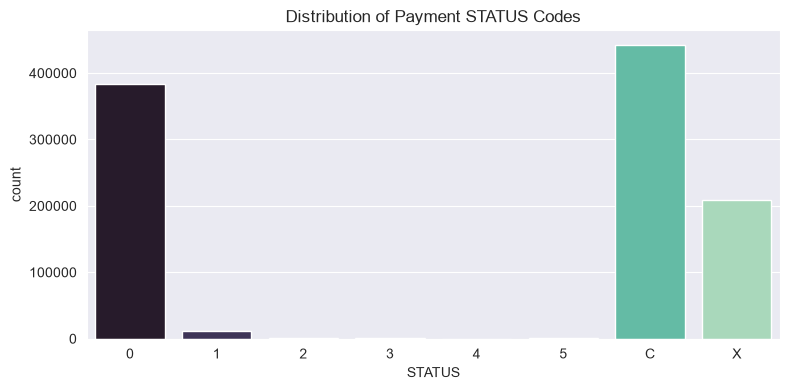

In [11]:
# 4. Target-adjacent: STATUS distribution in credit_record.csv
plt.figure(figsize=(8, 4))
sns.countplot(data=credit_df, x="STATUS", order=sorted(credit_df["STATUS"].unique()), palette="mako")
plt.title("Distribution of Payment STATUS Codes")
plt.tight_layout()
plt.show()

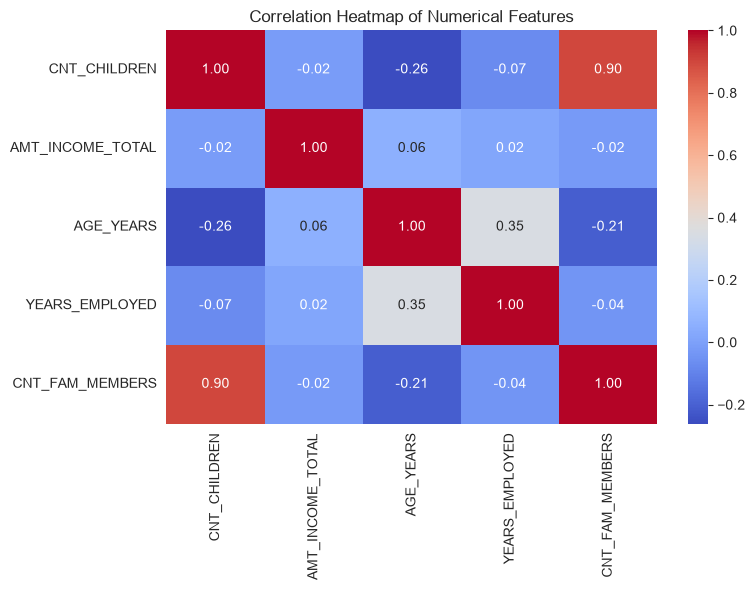

In [12]:
# --- Step 6: Multivariate Analysis ---

# 1. Correlation heatmap of numerical features
numerical_cols = ["CNT_CHILDREN", "AMT_INCOME_TOTAL", "AGE_YEARS",
                  "YEARS_EMPLOYED", "CNT_FAM_MEMBERS"]

# Exclude the DAYS_EMPLOYED placeholder rows for a meaningful correlation
clean_for_corr = application_df[application_df["DAYS_EMPLOYED"] != 365243]

plt.figure(figsize=(8, 6))
sns.heatmap(clean_for_corr[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

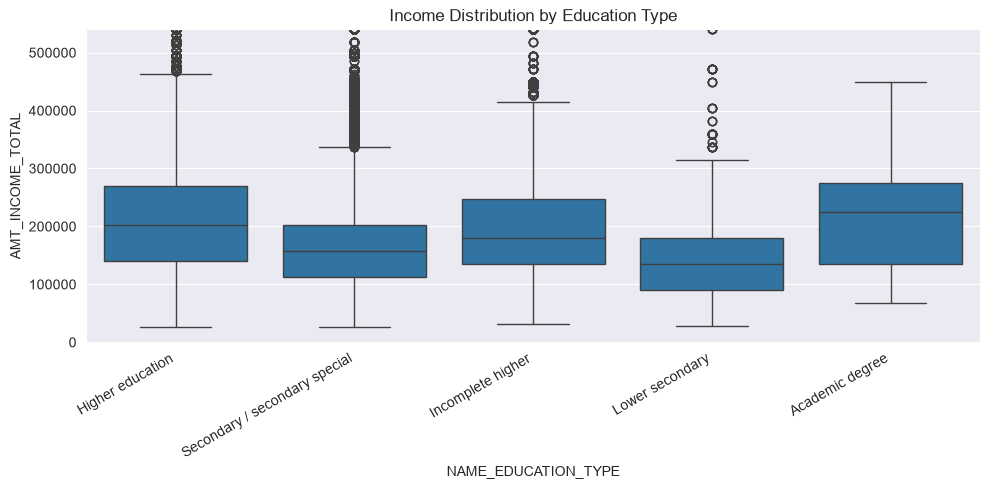

In [13]:
# 2. Income vs Education Type
plt.figure(figsize=(10, 5))
sns.boxplot(data=application_df, x="NAME_EDUCATION_TYPE", y="AMT_INCOME_TOTAL")
plt.xticks(rotation=30, ha="right")
plt.title("Income Distribution by Education Type")
plt.ylim(0, application_df["AMT_INCOME_TOTAL"].quantile(0.99))  # clip extreme outliers for readability
plt.tight_layout()
plt.show()

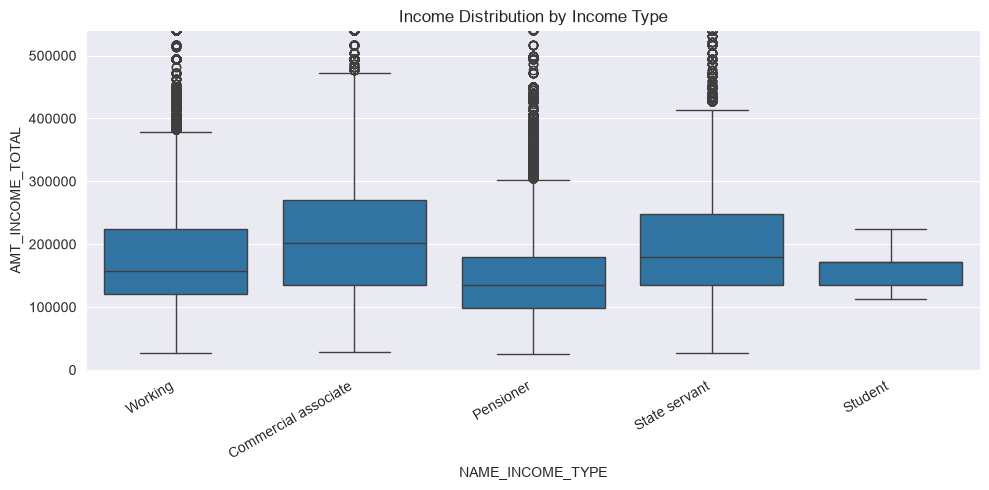

In [14]:
# 3. Income vs Income Type
plt.figure(figsize=(10, 5))
sns.boxplot(data=application_df, x="NAME_INCOME_TYPE", y="AMT_INCOME_TOTAL")
plt.xticks(rotation=30, ha="right")
plt.title("Income Distribution by Income Type")
plt.ylim(0, application_df["AMT_INCOME_TOTAL"].quantile(0.99))
plt.tight_layout()
plt.show()

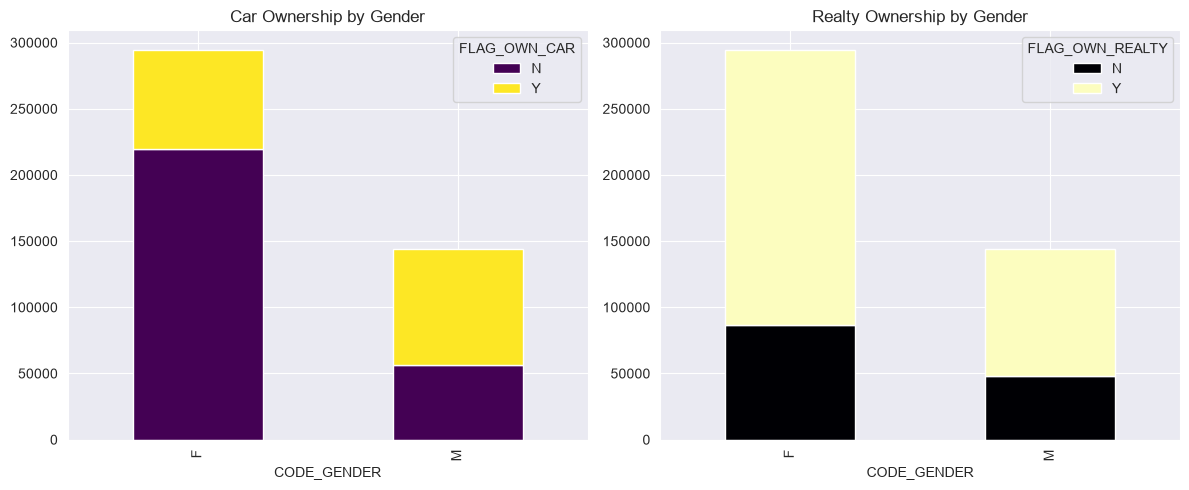

In [15]:
# 4. Gender vs Car/Realty ownership (cross-tab visualization)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pd.crosstab(application_df["CODE_GENDER"], application_df["FLAG_OWN_CAR"]).plot(
    kind="bar", stacked=True, ax=axes[0], colormap="viridis"
)
axes[0].set_title("Car Ownership by Gender")

pd.crosstab(application_df["CODE_GENDER"], application_df["FLAG_OWN_REALTY"]).plot(
    kind="bar", stacked=True, ax=axes[1], colormap="magma"
)
axes[1].set_title("Realty Ownership by Gender")

plt.tight_layout()
plt.show()

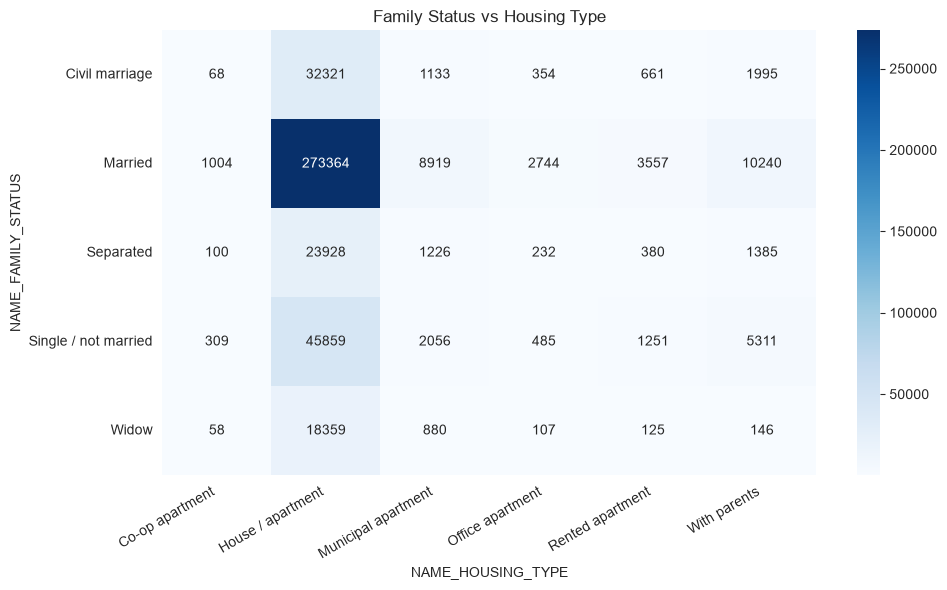

In [16]:
# 5. Family status vs Housing type (heatmap of counts)
cross = pd.crosstab(application_df["NAME_FAMILY_STATUS"], application_df["NAME_HOUSING_TYPE"])

plt.figure(figsize=(10, 6))
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues")
plt.title("Family Status vs Housing Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

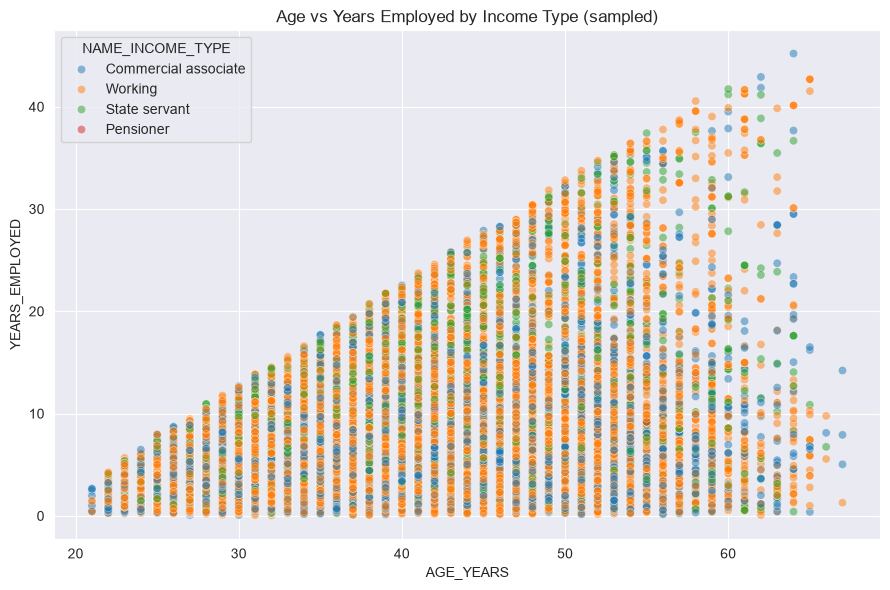

In [17]:
# 6. Age vs Years Employed, colored by Income Type (excluding placeholder)
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=clean_for_corr.sample(min(20000, len(clean_for_corr)), random_state=42),
    x="AGE_YEARS", y="YEARS_EMPLOYED", hue="NAME_INCOME_TYPE", alpha=0.5
)
plt.title("Age vs Years Employed by Income Type (sampled)")
plt.tight_layout()
plt.show()

In [18]:
# --- Step 7: Descriptive Analysis ---

# 1. Full statistical summary - numerical features
print("=== Numerical Features Summary ===")
display(application_df[["CNT_CHILDREN", "AMT_INCOME_TOTAL", "AGE_YEARS",
                         "YEARS_EMPLOYED", "CNT_FAM_MEMBERS"]].describe().T)

=== Numerical Features Summary ===


,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,438557.0,0.427390,0.724882,0.000000,0.000000,0.000000,1.00000,1.900000e+01
AMT_INCOME_TOTAL,438557.0,187524.286010,110086.853066,26100.000000,121500.000000,160780.500000,225000.00000,6.750000e+06
AGE_YEARS,438557.0,43.326489,11.467500,20.000000,34.000000,42.000000,53.00000,6.900000e+01
YEARS_EMPLOYED,438557.0,-165.927878,380.185752,-1000.665753,1.016438,4.019178,8.50137,4.803014e+01
CNT_FAM_MEMBERS,438557.0,2.194465,0.897207,1.000000,2.000000,2.000000,3.00000,2.000000e+01


In [19]:
# 2. Full statistical summary - categorical features
print("=== Categorical Features Summary ===")
categorical_cols = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
                    "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
                    "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(application_df[col].value_counts())
    print(f"Unique values: {application_df[col].nunique()}")

=== Categorical Features Summary ===

--- CODE_GENDER ---
CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64
Unique values: 2

--- FLAG_OWN_CAR ---
FLAG_OWN_CAR
N    275459
Y    163098
Name: count, dtype: int64


Unique values: 2

--- FLAG_OWN_REALTY ---
FLAG_OWN_REALTY
Y    304074
N    134483
Name: count, dtype: int64
Unique values: 2

--- NAME_INCOME_TYPE ---
NAME_INCOME_TYPE
Working                 226104
Commercial associate    100757
Pensioner                75493
State servant            36186
Student                     17
Name: count, dtype: int64
Unique values: 5

--- NAME_EDUCATION_TYPE ---
NAME_EDUCATION_TYPE
Secondary / secondary special    301821
Higher education                 117522
Incomplete higher                 14851
Lower secondary                    4051
Academic degree                     312
Name: count, dtype: int64
Unique values: 5

--- NAME_FAMILY_STATUS ---
NAME_FAMILY_STATUS
Married                 299828
Single / not married     55271
Civil marriage           36532
Separated                27251
Widow                    19675
Name: count, dtype: int64
Unique values: 5

--- NAME_HOUSING_TYPE ---
NAME_HOUSING_TYPE
House / apartment      393831
With parents          

In [20]:
# 3. Skewness & Kurtosis - flags which numerical features need transformation later
from scipy.stats import skew, kurtosis

numerical_cols = ["CNT_CHILDREN", "AMT_INCOME_TOTAL", "AGE_YEARS", "CNT_FAM_MEMBERS"]

skew_kurt = pd.DataFrame({
    "Skewness": [skew(application_df[col]) for col in numerical_cols],
    "Kurtosis": [kurtosis(application_df[col]) for col in numerical_cols]
}, index=numerical_cols)

display(skew_kurt)

,Skewness,Kurtosis
CNT_CHILDREN,1.806935,5.084814
AMT_INCOME_TOTAL,8.834036,324.546966
AGE_YEARS,0.160757,-1.047455
CNT_FAM_MEMBERS,0.919673,1.897453


In [21]:
# 4. Missing value summary
print("=== Missing Values ===")
missing = application_df.isnull().sum()
missing_pct = (missing / len(application_df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
display(missing_summary[missing_summary["Missing Count"] > 0])

=== Missing Values ===


,Missing Count,Missing %
OCCUPATION_TYPE,134203,30.6


In [22]:
# 5. Duplicate record check
print("Duplicate rows in application_record:", application_df.duplicated().sum())
print("Duplicate IDs in application_record:", application_df["ID"].duplicated().sum())
print("Duplicate rows in credit_record:", credit_df.duplicated().sum())

# 6. STATUS code breakdown in credit_record (this becomes your target label later)
print("=== STATUS Code Meaning ===")
status_meaning = {
    "0": "1-29 days past due",
    "1": "30-59 days past due",
    "2": "60-89 days past due",
    "3": "90-119 days past due",
    "4": "120-149 days past due",
    "5": "Overdue 150+ days or bad debt",
    "C": "Paid off that month",
    "X": "No loan for that month"
}
for code, meaning in status_meaning.items():
    count = (credit_df["STATUS"] == code).sum()
    print(f"{code} ({meaning}): {count}")

Duplicate rows in application_record: 0
Duplicate IDs in application_record: 47
Duplicate rows in credit_record: 0
=== STATUS Code Meaning ===
0 (1-29 days past due): 383120
1 (30-59 days past due): 11090
2 (60-89 days past due): 868
3 (90-119 days past due): 320
4 (120-149 days past due): 223
5 (Overdue 150+ days or bad debt): 1693
C (Paid off that month): 442031
X (No loan for that month): 209230


In [23]:
# --- Step 8: Drop Duplicate Features ---

# 1. Inspect the duplicate IDs before dropping anything
dup_ids = application_df[application_df["ID"].duplicated(keep=False)]
print("Rows involved in duplicate IDs:", dup_ids.shape[0])
dup_ids.sort_values("ID").head(10)

Rows involved in duplicate IDs: 94


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE_YEARS,YEARS_EMPLOYED
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,NaN,1.0,54,4.928767
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0,32,2.013699
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0,58,4.586301
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0,40,14.515068
425486,7023108,M,Y,Y,1,67500.0,Working,Secondary / secondary special,Married,House / apartment,-15156,-1696,1,1,0,0,Core staff,3.0,41,4.646575
426488,7023108,F,N,N,0,135000.0,Working,Secondary / secondary special,Married,House / apartment,-17590,-1273,1,0,0,0,Cleaning staff,2.0,48,3.487671
425306,7023651,F,N,N,0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229,-1209,1,0,0,0,Accountants,1.0,28,3.312329
421907,7023651,M,Y,N,1,157500.0,Commercial associate,Incomplete higher,Married,House / apartment,-10521,-1457,1,0,0,0,Drivers,3.0,28,3.991781
427778,7024111,M,N,N,2,157500.0,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,-15270,-117,1,1,0,0,Drivers,4.0,41,0.320548
432643,7024111,F,N,Y,0,180000.0,Working,Secondary / secondary special,Married,House / apartment,-22041,-1524,1,1,1,0,Accountants,2.0,60,4.175342


In [24]:
# 2. Check whether duplicate-ID rows are identical across all other columns too
# (if so, they're true duplicates; if not, they're conflicting records for the same ID)
dup_check = application_df[application_df.duplicated(subset="ID", keep=False)]
cols_no_id = [c for c in application_df.columns if c != "ID"]

fully_identical = dup_check.groupby("ID")[cols_no_id].apply(lambda x: x.duplicated(keep=False).all())
print("Duplicate IDs where all rows are fully identical:", fully_identical.sum())
print("Duplicate IDs with conflicting data:", (~fully_identical).sum())

Duplicate IDs where all rows are fully identical: 0
Duplicate IDs with conflicting data: 47


In [25]:
# 3. Drop duplicates, keeping the first occurrence per ID
before = application_df.shape[0]
application_df = application_df.drop_duplicates(subset="ID", keep="first").reset_index(drop=True)
after = application_df.shape[0]

print(f"Rows before: {before}, after: {after}, removed: {before - after}")
print("Remaining duplicate IDs:", application_df["ID"].duplicated().sum())

Rows before: 438557, after: 438510, removed: 47
Remaining duplicate IDs: 0


In [26]:
# --- Step 9: Handling Missing Values ---

# 1. Confirm which columns have missing values (should just be OCCUPATION_TYPE at this point)
missing = application_df.isnull().sum()
print(missing[missing > 0])

OCCUPATION_TYPE    134193
dtype: int64


In [27]:
# 2. Inspect who's missing OCCUPATION_TYPE - is there a pattern?
missing_occ = application_df[application_df["OCCUPATION_TYPE"].isnull()]

print("Rows missing OCCUPATION_TYPE:", missing_occ.shape[0])
print("\nIncome type breakdown for missing OCCUPATION_TYPE:")
print(missing_occ["NAME_INCOME_TYPE"].value_counts())

# 3. Handle it: missing OCCUPATION_TYPE is very likely tied to Pensioners/non-working applicants
# rather than a data entry gap - so we fill with an explicit "Not Employed" category
# instead of the column mean/mode, which would be misleading here.

application_df["OCCUPATION_TYPE"] = application_df["OCCUPATION_TYPE"].fillna("Not Employed")

# Confirm no missing values remain
print("Remaining missing values:\n", application_df.isnull().sum().sum())

Rows missing OCCUPATION_TYPE: 134193

Income type breakdown for missing OCCUPATION_TYPE:
NAME_INCOME_TYPE
Pensioner               75352
Working                 35884
Commercial associate    16742
State servant            6210
Student                     5
Name: count, dtype: int64
Remaining missing values:
 0


In [28]:
# --- Step 10: Data Cleaning and Merging ---

# 1. Aggregate credit_record.csv per applicant: did they EVER hit STATUS 2 or worse?
# STATUS 2,3,4,5 = 60+ days overdue -> treated as high-risk / rejected
# STATUS 0,1,C,X = on-time, paid off, or no active loan that month -> not high-risk

high_risk_statuses = ["2", "3", "4", "5"]

credit_df["IS_HIGH_RISK"] = credit_df["STATUS"].isin(high_risk_statuses).astype(int)

# Aggregate: if an applicant EVER had a high-risk month, they're high-risk overall
risk_summary = credit_df.groupby("ID")["IS_HIGH_RISK"].max().reset_index()
risk_summary.rename(columns={"IS_HIGH_RISK": "TARGET"}, inplace=True)

print("Total applicants with credit history:", risk_summary.shape[0])
print("High-risk applicants:", risk_summary["TARGET"].sum())
print("Class balance:\n", risk_summary["TARGET"].value_counts(normalize=True))

Total applicants with credit history: 45985
High-risk applicants: 667
Class balance:
 TARGET
0    0.985495
1    0.014505
Name: proportion, dtype: float64


In [29]:
# 2. Merge application data with the risk summary
# Inner join: only keep applicants who have BOTH demographic data AND credit history
merged_df = pd.merge(application_df, risk_summary, on="ID", how="inner")

print("Merged dataset shape:", merged_df.shape)
merged_df.head()

# 3. Sanity check: confirm merge didn't create duplicate rows (many-to-many blowup)
print("Duplicate IDs after merge:", merged_df["ID"].duplicated().sum())
print("Expected rows (unique overlapping IDs):", len(set(application_df["ID"]) & set(risk_summary["ID"])))

Merged dataset shape: (36457, 21)
Duplicate IDs after merge: 0
Expected rows (unique overlapping IDs): 36457


In [30]:
# 4. Final target distribution check on the merged dataset
print("=== Final TARGET distribution ===")
print(merged_df["TARGET"].value_counts())
print(merged_df["TARGET"].value_counts(normalize=True).round(4) * 100, "%")

# 5. Drop columns that won't help the model
# FLAG_MOBIL is always 1 (constant, no signal) - safe to drop
print("FLAG_MOBIL unique values:", merged_df["FLAG_MOBIL"].unique())

merged_df.drop(columns=["FLAG_MOBIL"], inplace=True)

=== Final TARGET distribution ===
TARGET
0    35841
1      616
Name: count, dtype: int64
TARGET
0    98.31
1     1.69
Name: proportion, dtype: float64 %
FLAG_MOBIL unique values: [1]


In [31]:
# --- Step 11: Feature Engineering ---

# 1. Convert DAYS_BIRTH and DAYS_EMPLOYED into human-readable, model-friendly features
merged_df["AGE_YEARS"] = (-merged_df["DAYS_BIRTH"] / 365).astype(int)

# Handle the DAYS_EMPLOYED placeholder (365243 = pensioner/not currently employed)
merged_df["IS_EMPLOYED"] = (merged_df["DAYS_EMPLOYED"] != 365243).astype(int)
merged_df["YEARS_EMPLOYED"] = np.where(
    merged_df["DAYS_EMPLOYED"] != 365243,
    -merged_df["DAYS_EMPLOYED"] / 365,
    0  # not employed -> 0 years, IS_EMPLOYED flag already captures this separately
)

merged_df.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED"], inplace=True)

In [32]:
# 2. Income per family member - captures financial burden better than raw income alone
merged_df["INCOME_PER_PERSON"] = merged_df["AMT_INCOME_TOTAL"] / merged_df["CNT_FAM_MEMBERS"]

# 3. Log-transform income to reduce right-skew (you saw this skew back in Step 7)
merged_df["LOG_INCOME"] = np.log1p(merged_df["AMT_INCOME_TOTAL"])

# 4. Simplify OCCUPATION_TYPE - 18 categories is a lot for ~36k rows with 1.69% positives.
# Group rare occupations (<1% of data) into "Other" to avoid overfitting on sparse categories
occ_counts = merged_df["OCCUPATION_TYPE"].value_counts(normalize=True)
rare_occupations = occ_counts[occ_counts < 0.01].index

merged_df["OCCUPATION_TYPE"] = merged_df["OCCUPATION_TYPE"].apply(
    lambda x: "Other" if x in rare_occupations else x
)

print("Occupation categories after grouping:", merged_df["OCCUPATION_TYPE"].nunique())
print(merged_df["OCCUPATION_TYPE"].value_counts())

Occupation categories after grouping: 13
OCCUPATION_TYPE
Not Employed             11323
Laborers                  6211
Core staff                3591
Sales staff               3485
Managers                  3012
Drivers                   2138
High skill tech staff     1383
Accountants               1241
Medicine staff            1207
Other                     1068
Cooking staff              655
Security staff             592
Cleaning staff             551
Name: count, dtype: int64


In [33]:
# Save the exact occupation categories the model will be trained 
occupation_model_categories = sorted(merged_df["OCCUPATION_TYPE"].unique().tolist())

In [34]:
# 5. Combine flag columns into a single "digital engagement" score (optional but useful signal)
merged_df["CONTACT_SCORE"] = (
    merged_df["FLAG_WORK_PHONE"] + merged_df["FLAG_PHONE"] + merged_df["FLAG_EMAIL"]
)

# 6. Quick check of the engineered dataset
merged_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE_YEARS,YEARS_EMPLOYED,TARGET,IS_EMPLOYED,INCOME_PER_PERSON,LOG_INCOME,CONTACT_SCORE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,Not Employed,2.0,32,12.443836,0,1,213750.0,12.965712,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0,Not Employed,2.0,32,12.443836,0,1,213750.0,12.965712,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,Security staff,2.0,58,3.106849,0,1,56250.0,11.630717,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,Sales staff,1.0,52,8.358904,0,1,270000.0,12.506181,2
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1,Sales staff,1.0,52,8.358904,0,1,270000.0,12.506181,2


In [35]:
# --- Step 12: Handling Categorical Values ---

# 1. Separate binary (Y/N) flags from multi-category features
binary_cols = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY"]
multi_cat_cols = ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
                   "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]

# 2. Encode binary columns with LabelEncoder (M/F, Y/N -> 0/1)
le = LabelEncoder()
for col in binary_cols:
    merged_df[col] = le.fit_transform(merged_df[col])
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

CODE_GENDER: {'F': np.int64(0), 'M': np.int64(1)}
FLAG_OWN_CAR: {'N': np.int64(0), 'Y': np.int64(1)}
FLAG_OWN_REALTY: {'N': np.int64(0), 'Y': np.int64(1)}


In [36]:
# 3. One-hot encode multi-category columns
# drop_first=True avoids the dummy variable trap (redundant, perfectly correlated columns)
merged_df = pd.get_dummies(merged_df, columns=multi_cat_cols, drop_first=True)

print("Shape after encoding:", merged_df.shape)
merged_df.head()

Shape after encoding: (36457, 46)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,...,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Not Employed,OCCUPATION_TYPE_Other,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Security staff
0,5008804,1,1,1,0,427500.0,1,0,0,2.0,...,False,False,False,False,False,False,True,False,False,False
1,5008805,1,1,1,0,427500.0,1,0,0,2.0,...,False,False,False,False,False,False,True,False,False,False
2,5008806,1,1,1,0,112500.0,0,0,0,2.0,...,False,False,False,False,False,False,False,False,False,True
3,5008808,0,0,1,0,270000.0,0,1,1,1.0,...,False,False,False,False,False,False,False,False,True,False
4,5008809,0,0,1,0,270000.0,0,1,1,1.0,...,False,False,False,False,False,False,False,False,True,False


In [37]:
# 4. Confirm no object/categorical columns remain - everything should be numeric now
print(merged_df.dtypes.value_counts())
remaining_object_cols = merged_df.select_dtypes(include="object").columns.tolist()
print("Remaining non-numeric columns:", remaining_object_cols)

# 5. Final feature/target split, ready for modeling
X = merged_df.drop(columns=["ID", "TARGET"])
y = merged_df["TARGET"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

bool       29
int64      12
float64     5
Name: count, dtype: int64
Remaining non-numeric columns: []
Feature matrix shape: (36457, 44)
Target shape: (36457,)
Target distribution:
 TARGET
0    0.983103
1    0.016897
Name: proportion, dtype: float64


In [38]:
# --- Step 13: Logistic Regression Model ---

# 1. Train/test split - stratify to preserve the 1.69% positive rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train positive rate:", y_train.mean().round(4))
print("Test positive rate:", y_test.mean().round(4))

Train shape: (29165, 44) Test shape: (7292, 44)
Train positive rate: 0.0169
Test positive rate: 0.0169


In [39]:
# 2. Scale numerical features - Logistic Regression is sensitive to feature scale,
# unlike tree-based models we'll use later
scaler = StandardScaler()

numerical_features = ["CNT_CHILDREN", "AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS",
                       "AGE_YEARS", "YEARS_EMPLOYED", "INCOME_PER_PERSON",
                       "LOG_INCOME", "CONTACT_SCORE"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

In [40]:
# 3. Train Logistic Regression with class_weight="balanced" to counter the 1.69% imbalance
# Without this, the model would likely just predict "0" for everyone
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [41]:
# 4. Predict and evaluate
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

=== Logistic Regression Results ===
Accuracy: 0.6193088315962699
ROC-AUC: 0.5645121781110405

Confusion Matrix:
[[4460 2709]
 [  67   56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.62      0.76      7169
           1       0.02      0.46      0.04       123

    accuracy                           0.62      7292
   macro avg       0.50      0.54      0.40      7292
weighted avg       0.97      0.62      0.75      7292



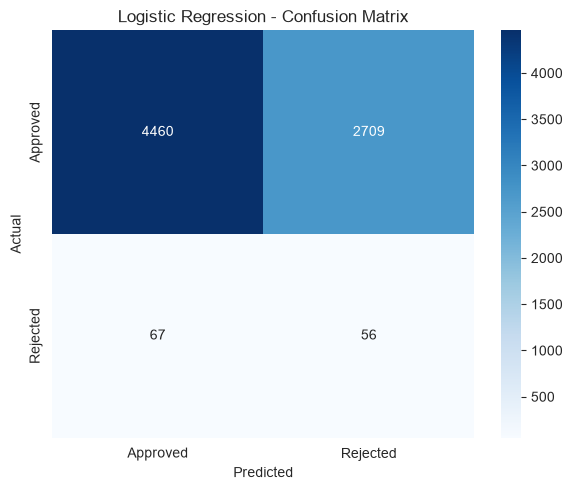

In [42]:
# 5. Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Approved", "Rejected"], yticklabels=["Approved", "Rejected"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [43]:
# --- Step 14: Random Forest Model ---
# Tree-based model - no scaling needed, use the unscaled train/test split

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,           # keep shallow-ish to limit overfitting given the small positive class
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_featu

In [44]:
# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest Results ===
Accuracy: 0.855595172792101
ROC-AUC: 0.6560274760231213

Confusion Matrix:
[[6190  979]
 [  74   49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7169
           1       0.05      0.40      0.09       123

    accuracy                           0.86      7292
   macro avg       0.52      0.63      0.50      7292
weighted avg       0.97      0.86      0.91      7292



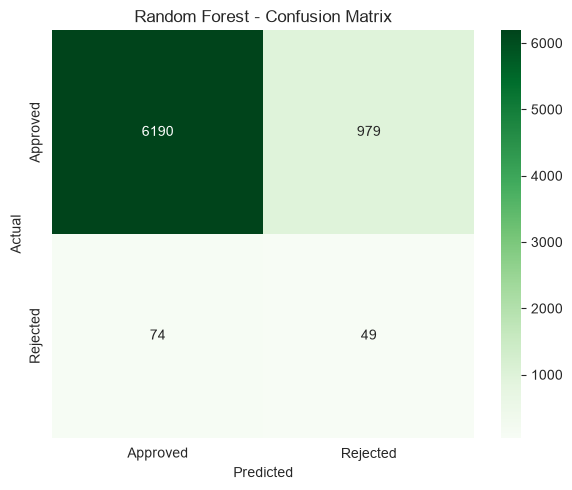

In [45]:
# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Greens",
            xticklabels=["Approved", "Rejected"], yticklabels=["Approved", "Rejected"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

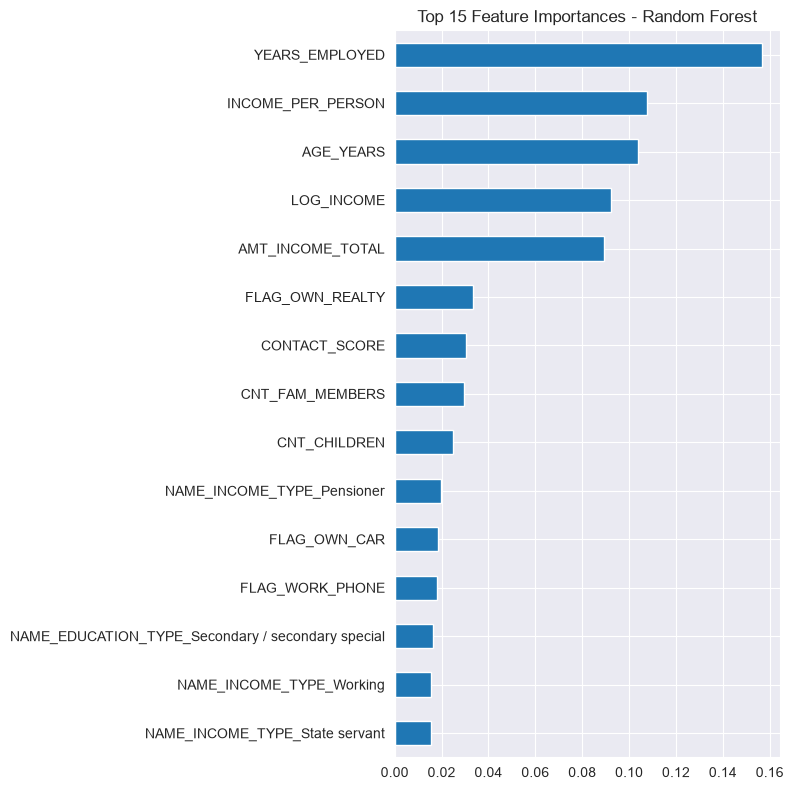

In [46]:
# Feature importance - worth checking whether anything stands out as genuinely predictive
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [47]:
# --- Step 15: Decision Tree Model ---

dt_model = DecisionTreeClassifier(
    max_depth=6,             # shallow tree to limit overfitting on the small positive class
    class_weight="balanced",
    random_state=42
)
dt_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

In [48]:
# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

print("=== Decision Tree Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

=== Decision Tree Results ===
Accuracy: 0.856006582556226
ROC-AUC: 0.5860372176047048

Confusion Matrix:
[[6209  960]
 [  90   33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.92      7169
           1       0.03      0.27      0.06       123

    accuracy                           0.86      7292
   macro avg       0.51      0.57      0.49      7292
weighted avg       0.97      0.86      0.91      7292



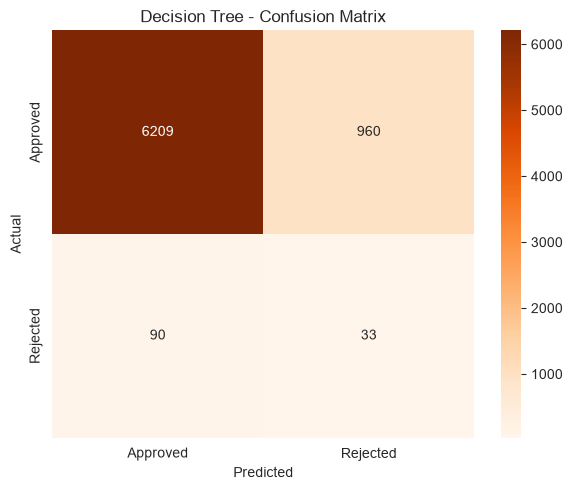

In [49]:
# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Approved", "Rejected"], yticklabels=["Approved", "Rejected"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

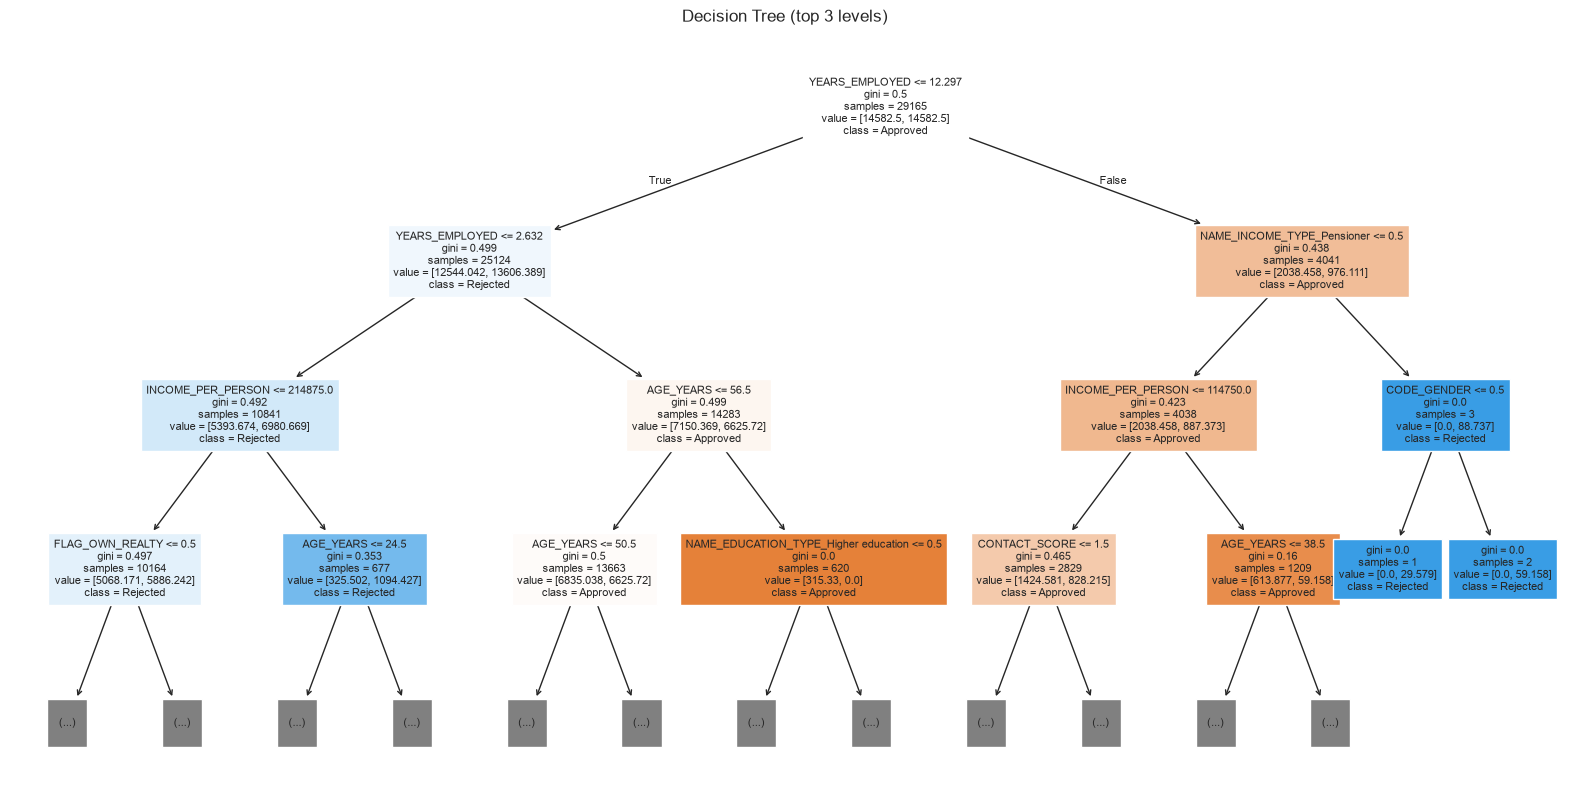

In [50]:
# Visualize the tree structure itself - useful for the "why" behind a rejection
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=["Approved", "Rejected"],
          filled=True, max_depth=3, fontsize=8)  # only show top 3 levels for readability
plt.title("Decision Tree (top 3 levels)")
plt.show()

In [51]:
# --- XGBoost Model (missing from board, present in Instructions) ---

# scale_pos_weight approximates class_weight="balanced" for XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

scale_pos_weight: 58.15821501014199


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [52]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost Results ===
Accuracy: 0.8794569391113549
ROC-AUC: 0.7123381270079963

Confusion Matrix:
[[6354  815]
 [  64   59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      7169
           1       0.07      0.48      0.12       123

    accuracy                           0.88      7292
   macro avg       0.53      0.68      0.53      7292
weighted avg       0.97      0.88      0.92      7292



,Model,Accuracy,ROC_AUC
3,XGBoost,0.879457,0.712338
1,Random Forest,0.924700,0.645800
2,Decision Tree,0.856000,0.586000
0,Logistic Regression,0.620400,0.564800


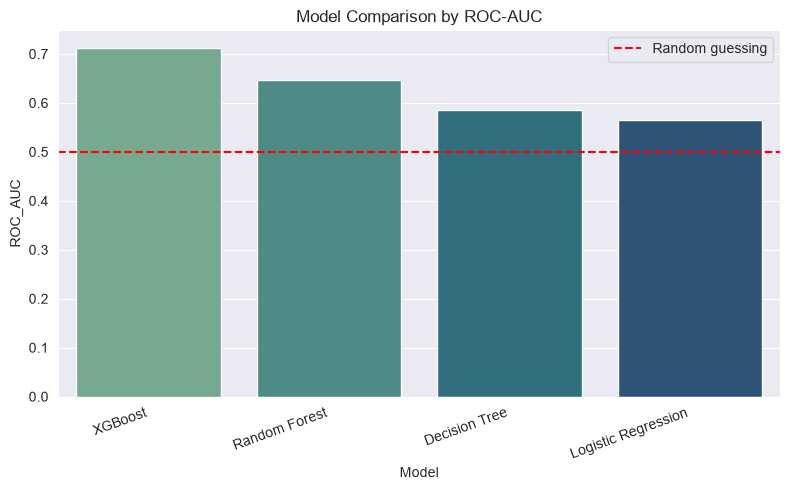

In [53]:
# --- Model Comparison (Epic 4, Story 4) ---
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Decision Tree", "XGBoost"],
    "Accuracy": [0.6204, 0.9247, 0.8560, accuracy_score(y_test, y_pred_xgb)],
    "ROC_AUC": [0.5648, 0.6458, 0.5860, roc_auc_score(y_test, y_proba_xgb)]
}).sort_values("ROC_AUC", ascending=False)

display(results)

plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="ROC_AUC", palette="crest")
plt.xticks(rotation=20, ha="right")
plt.title("Model Comparison by ROC-AUC")
plt.axhline(0.5, color="red", linestyle="--", label="Random guessing")
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
# --- Efficiency Step 1: Stratified K-Fold baseline (trustworthy evaluation) ---
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    random_state=42, n_jobs=-1
)

cv_scores = cross_val_score(baseline_xgb, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
print("CV ROC-AUC scores:", cv_scores)
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

CV ROC-AUC scores: [0.72134711 0.69762396 0.73759958 0.74533382 0.73953116]
Mean: 0.7283  |  Std: 0.0173


In [55]:
# --- Efficiency Step 2: Hyperparameter tuning via RandomizedSearchCV ---
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "scale_pos_weight": [scale_pos_weight * f for f in [0.5, 0.75, 1.0, 1.25, 1.5]]
}

search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best CV ROC-AUC:", search.best_score_)
print("Best params:", search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV ROC-AUC: 0.7680869663770269
Best params: {'subsample': 0.9, 'scale_pos_weight': np.float64(87.23732251521298), 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [56]:
# --- Efficiency Step 3: Evaluate tuned model on the held-out test set ---
tuned_xgb = search.best_estimator_

y_pred_tuned = tuned_xgb.predict(X_test)
y_proba_tuned = tuned_xgb.predict_proba(X_test)[:, 1]

print("=== Tuned XGBoost Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

=== Tuned XGBoost Results ===
Accuracy: 0.9578990674712013
ROC-AUC: 0.7212042137160107

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.19      0.46      0.27       123

    accuracy                           0.96      7292
   macro avg       0.59      0.71      0.62      7292
weighted avg       0.98      0.96      0.97      7292



In [57]:
# --- Efficiency Step 4: Diagnostic - does a looser label threshold help? ---
# Currently: high-risk = STATUS 2+ (60+ days overdue), only 616 positives.
# Test whether including STATUS 1 (30-59 days) as "risky" gives the model
# more positive examples to learn from, potentially improving signal.

high_risk_loose = ["1", "2", "3", "4", "5"]
credit_df["IS_HIGH_RISK_LOOSE"] = credit_df["STATUS"].isin(high_risk_loose).astype(int)
risk_summary_loose = credit_df.groupby("ID")["IS_HIGH_RISK_LOOSE"].max().reset_index()
risk_summary_loose.rename(columns={"IS_HIGH_RISK_LOOSE": "TARGET_LOOSE"}, inplace=True)

print("Positive rate with loose threshold:", risk_summary_loose["TARGET_LOOSE"].mean())
print("vs. original threshold:", y.mean())

# Only proceed to retrain on this if the positive count is meaningfully larger -
# this cell is diagnostic first, not an automatic swap

Positive rate with loose threshold: 0.11634228552788953
vs. original threshold: 0.016896617933455853


In [58]:
# --- Retrain on the loose threshold (STATUS 1+ = high-risk) ---

merged_loose = pd.merge(application_df, risk_summary_loose, on="ID", how="inner")
merged_loose.drop(columns=["FLAG_MOBIL"], inplace=True, errors="ignore")

# Re-apply the exact same feature engineering as Step 11
merged_loose["AGE_YEARS"] = (-merged_loose["DAYS_BIRTH"] / 365).astype(int)
merged_loose["IS_EMPLOYED"] = (merged_loose["DAYS_EMPLOYED"] != 365243).astype(int)
merged_loose["YEARS_EMPLOYED"] = np.where(
    merged_loose["DAYS_EMPLOYED"] != 365243, -merged_loose["DAYS_EMPLOYED"] / 365, 0
)
merged_loose.drop(columns=["DAYS_BIRTH", "DAYS_EMPLOYED"], inplace=True)
merged_loose["INCOME_PER_PERSON"] = merged_loose["AMT_INCOME_TOTAL"] / merged_loose["CNT_FAM_MEMBERS"]
merged_loose["LOG_INCOME"] = np.log1p(merged_loose["AMT_INCOME_TOTAL"])

occ_counts_loose = merged_loose["OCCUPATION_TYPE"].value_counts(normalize=True)
rare_occ_loose = occ_counts_loose[occ_counts_loose < 0.01].index
merged_loose["OCCUPATION_TYPE"] = merged_loose["OCCUPATION_TYPE"].apply(
    lambda x: "Other" if x in rare_occ_loose else x
)
merged_loose["CONTACT_SCORE"] = (
    merged_loose["FLAG_WORK_PHONE"] + merged_loose["FLAG_PHONE"] + merged_loose["FLAG_EMAIL"]
)

# Same encoding as Step 12
for col in ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY"]:
    merged_loose[col] = LabelEncoder().fit_transform(merged_loose[col])

multi_cat_cols = ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
                   "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]
merged_loose = pd.get_dummies(merged_loose, columns=multi_cat_cols, drop_first=True)

X_loose = merged_loose.drop(columns=["ID", "TARGET_LOOSE"])
y_loose = merged_loose["TARGET_LOOSE"]

print("New dataset shape:", X_loose.shape)
print("Positive rate:", y_loose.mean())

New dataset shape: (36457, 44)
Positive rate: 0.1177003044682777


In [59]:
# --- Evaluate with the same CV + tuning approach, on the loose-threshold target ---
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_loose, y_loose, test_size=0.2, random_state=42, stratify=y_loose
)

neg_l, pos_l = (y_train_l == 0).sum(), (y_train_l == 1).sum()
scale_pos_weight_l = neg_l / pos_l

cv_scores_loose = cross_val_score(
    XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                  scale_pos_weight=scale_pos_weight_l, eval_metric="logloss",
                  random_state=42, n_jobs=-1),
    X_loose, y_loose, cv=skf, scoring="roc_auc", n_jobs=-1
)
print("Loose-threshold CV ROC-AUC:", cv_scores_loose.mean(), "±", cv_scores_loose.std())

Loose-threshold CV ROC-AUC: 0.6776579584942913 ± 0.006451352988560565


In [60]:
# --- Finalize: retrain tuned XGBoost on strict-threshold target, save for deployment ---

final_model = XGBClassifier(
    subsample=0.9,
    scale_pos_weight=scale_pos_weight,   # original strict-threshold ratio, NOT the loose one
    n_estimators=600,
    min_child_weight=3,
    max_depth=8,
    learning_rate=0.1,
    colsample_bytree=1.0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train, y_train)  # back to original X_train/y_train (strict threshold)

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

print("=== Final Tuned XGBoost (strict threshold) ===")
print("ROC-AUC:", roc_auc_score(y_test, y_proba_final))
print(classification_report(y_test, y_pred_final))

=== Final Tuned XGBoost (strict threshold) ===
ROC-AUC: 0.7171454103995636
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.19      0.46      0.27       123

    accuracy                           0.96      7292
   macro avg       0.59      0.71      0.62      7292
weighted avg       0.98      0.96      0.97      7292



In [61]:
# --- Save final artifacts for Flask deployment ---
# Uses the TUNED final_model (not the earlier untuned xgb_model) - this is
# the single source of truth for what gets deployed.

joblib.dump(final_model, "best_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")

# categorical_value_map: raw category values for populating Flask dropdowns.
# Pulled from application_df BEFORE one-hot encoding, so every category is present -
# including the one pd.get_dummies(..., drop_first=True) drops from the encoded columns.
categorical_value_map = {
    "NAME_INCOME_TYPE": application_df["NAME_INCOME_TYPE"].unique().tolist(),
    "NAME_EDUCATION_TYPE": application_df["NAME_EDUCATION_TYPE"].unique().tolist(),
    "NAME_FAMILY_STATUS": application_df["NAME_FAMILY_STATUS"].unique().tolist(),
    "NAME_HOUSING_TYPE": application_df["NAME_HOUSING_TYPE"].unique().tolist(),
    "OCCUPATION_TYPE": sorted(application_df["OCCUPATION_TYPE"].fillna("Not Employed").unique().tolist())
}
joblib.dump(categorical_value_map, "categorical_value_map.pkl")

print("Saved: best_model.pkl, model_columns.pkl, categorical_value_map.pkl")


Saved: best_model.pkl, model_columns.pkl, categorical_value_map.pkl
